In [1]:
import tvm
from tvm import IRModule, relax
from tvm.relax.frontend import nn
import os

# Network transformation example

In [3]:
class NNModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        return x

In [4]:
origin_mod, params = NNModule().export_tvm(
    {"forward": {"x": nn.spec.Tensor(("n", 784), "float32")}}
)
origin_mod.show()

In [5]:
mod = tvm.relax.transform.LegalizeOps()(origin_mod)
mod.show()

In [5]:
mod = tvm.ir.transform.Sequential(
    [
        tvm.relax.transform.AnnotateTIROpPattern(),
        tvm.relax.transform.FuseOps(),
        tvm.relax.transform.FuseTIR(),
    ]
)(mod)
mod.show()

## Relu to Gelu

In [ ]:
from tvm.relax.expr_functor import PyExprMutator, mutator


@mutator
class ReluRewriter(PyExprMutator):
    def __init__(self, mod):
        super().__init__(mod)

    def visit_call_(self, call: relax.Call) -> relax.Expr:
        # visit the relax.Call expr, and only handle the case when op is relax.nn.relu
        if call.op.name == "relax.nn.relu":
            return relax.op.nn.gelu(call.args[0])

        return super().visit_call_(call)

In [7]:
@tvm.transform.module_pass(opt_level=0, name="ReluToGelu")
class ReluToGelu:  # pylint: disable=too-few-public-methods
    def transform_module(self, mod: IRModule, _ctx: tvm.transform.PassContext) -> IRModule:
        """IRModule-level transformation"""
        rewriter = ReluRewriter(mod)
        for g_var, func in mod.functions_items():
            if isinstance(func, relax.Function):
                func = rewriter.visit_expr(func)
                rewriter.builder_.update_func(g_var, func)
        return rewriter.builder_.get()


mod = ReluToGelu()(origin_mod)
mod.show()

# Softmax Experiment

In [2]:
class NNModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = nn.softmax(x)

        return x
    
origin_mod, params = NNModule().export_tvm(
    {"forward": {"x": nn.spec.Tensor(("n", 4), "float32")}}
)
origin_mod.show()

In [3]:
import tvm.te as te
import tvm.tir as tir
from tvm.relax.expr import Call
from tvm.te import create_prim_func
from tvm.relax.expr_functor import PyExprMutator, mutator

In [4]:
def _poly_exp_expr(xi):
    """
    Return a tir expression for exp(xi).
    xi must be a tir scalar expression (float32).
    """
    def f32(v): return tir.const(v, "float32")
    def i32(v): return tir.const(v, "int32")
 
    # minimax polynomial coefficients for exp(r), r in [-ln2/2, ln2/2]
    C0 = f32(1.0000000000)
    C1 = f32(1.0000000000)
    C2 = f32(0.4999999940)
    C3 = f32(0.1666666418)
    C4 = f32(0.0416666269)
    C5 = f32(0.0083333648)
    C6 = f32(0.0013885417)
    LOG2E  = f32(1.44269504088896340736)
    LN2_HI = f32(6.93147180369123816490e-01)
    LN2_LO = f32(1.90821492927058770002e-10)
    HALF   = f32(0.5)
    BIAS   = i32(127)
    SHIFT  = i32(23)
 
    # clamp to avoid inf/nan
    xc = tir.max(tir.min(xi, f32(88.0)), f32(-88.0))
 
    # range reduction: x = k*ln2 + r,  r in [-ln2/2, ln2/2]
    k_f = tir.floor(xc * LOG2E + HALF)
    r   = xc - k_f * LN2_HI - k_f * LN2_LO
 
    # degree-6 Horner evaluation of exp(r)
    p = C6
    p = p * r + C5
    p = p * r + C4
    p = p * r + C3
    p = p * r + C2
    p = p * r + C1
    p = p * r + C0
 
    k_i   = tir.Cast("int32", k_f)
    scale = tir.reinterpret("float32", (k_i + BIAS) << SHIFT)
    return p * scale

In [5]:
def make_fast_softmax_primfunc(features: int = 1):
    """Return a TIR PrimFunc for fast softmax over the last axis."""
    DTYPE = "float32"
    batch = te.var("batch", dtype="int32")

    data  = te.placeholder((batch, features), dtype=DTYPE, name="data")
    k_max = te.reduce_axis((0, features), name="k_max")
    row_max = te.compute(
        (batch,),
        lambda b: te.max(data[b, k_max], axis=k_max),
        name="row_max",
    )
    exp_vals = te.compute(
        (batch, features),
        lambda b, f: _poly_exp_expr(data[b, f] - row_max[b]),
        name="exp_vals",
    )
    k_sum = te.reduce_axis((0, features), name="k_sum")
    exp_sum = te.compute(
        (batch,),
        lambda b: te.sum(exp_vals[b, k_sum], axis=k_sum),
        name="exp_sum",
    )
    out = te.compute(
        (batch, features),
        lambda b, f: exp_vals[b, f] / exp_sum[b],
        name="softmax_out",
    )
    prim_func = te.create_prim_func([data, out])

    prim_func = prim_func.with_attr({
        "global_symbol": "fast_softmax",
        "tir.noalias": True,
        "tir.is_scheduled": 1,
    })
    return prim_func

In [6]:
fast_softmax_prim_func = make_fast_softmax_primfunc(features=1)
fast_softmax_ir_mod = IRModule({"fast_softmax": fast_softmax_prim_func})

In [7]:
@mutator
class SoftmaxRewriter(PyExprMutator):
    def __init__(self, mod: IRModule):
        super().__init__(mod)
        func = fast_softmax_prim_func.with_attr({
            "tir.noalias": True,
            "tir.is_scheduled": False,
        })
        self._fast_softmax_gvar = self.builder_.add_func(func, "fast_softmax")

    def visit_call_(self, call: relax.Call) -> relax.Expr:
        # Only rewrite relax.nn.softmax calls
        if not isinstance(call.op, tvm.ir.Op):
            return super().visit_call_(call)
        if call.op.name != "relax.nn.softmax":
            return super().visit_call_(call)

        inp = call.args[0]

        out_sinfo = call.struct_info

        return self.builder_.emit(
            relax.call_tir(
                self._fast_softmax_gvar,
                args=[inp],
                out_sinfo=out_sinfo,
            )
        )

In [8]:
@tvm.transform.module_pass(opt_level=0, name="SoftmaxToFastSoftmax")
class SoftmaxToFastSoftmax:  # pylint: disable=too-few-public-methods
    def transform_module(self, mod: IRModule, _ctx: tvm.transform.PassContext) -> IRModule:
        """IRModule-level transformation"""
        rewriter = SoftmaxRewriter(mod)
        for g_var, func in mod.functions_items():
            if isinstance(func, relax.Function):
                func = rewriter.visit_expr(func)
                rewriter.builder_.update_func(g_var, func)
        return rewriter.builder_.get()


mod = SoftmaxToFastSoftmax()(origin_mod)
mod.show()

## Tuning

In [9]:
def exclude_fast_softmax_from_tuning(mod):
    """
    Mark fast_softmax with all attrs that tell every TVM tuning/lowering
    pass to leave it completely alone.
    """
    gvar = mod.get_global_var("fast_softmax")
    prim_func = mod[gvar]

    # These three attrs together make the function fully opaque to tuning:
    # 1. tir.is_scheduled=True  → MetaSchedule won't generate candidates
    # 2. tir.noalias=True       → keeps existing noalias hint
    # 3. tir.is_entry_func=False → not an entry, won't be serialized as task
    prim_func = prim_func.with_attr("tir.is_scheduled", True)
    prim_func = prim_func.with_attr("tir.noalias", True)

    new_mod = tvm.IRModule(dict(mod.functions))
    new_mod.update_func(gvar, prim_func)
    return new_mod

In [10]:
STATIC_BATCH = 1
mod_static = relax.transform.BindSymbolicVars({"n": STATIC_BATCH})(mod)
mod_static = exclude_fast_softmax_from_tuning(mod_static)

In [11]:
TOTAL_TRIALS = 512
MAX_TRIALS_PER_TASK = 16 
RISCV_TARGET = tvm.target.Target({
    "kind": "llvm",
    "mtriple": "riscv64-linux-gnu",
    "mcpu": "generic-rv64",
    "mattr": ["+64bit", "+m", "+a", "+f", "+d", "+c", "+v"],
    "num-cores": 4,
})
work_dir = "tuning_logs"

mod = relax.get_pipeline(
    "static_shape_tuning",
    target=RISCV_TARGET,
    work_dir=work_dir,
    total_trials=TOTAL_TRIALS,
    max_trials_per_task=MAX_TRIALS_PER_TASK,
)(mod_static)

mod.show()

2026-03-31 15:36:43 [INFO] Logging directory: tuning_logs/logs
2026-03-31 15:36:49 [INFO] LocalBuilder: max_workers = 8
2026-03-31 15:36:49 [INFO] LocalRunner: max_workers = 1
2026-03-31 15:36:49 [INFO] [task_scheduler.cc:168] Initializing Task #0: "fast_softmax"
2026-03-31 15:36:49 [INFO] [task_scheduler.cc:168] Initializing Task #1: "fused_matmul_add"
2026-03-31 15:36:49 [INFO] [task_scheduler.cc:168] Initializing Task #2: "transpose"


,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,fast_softmax,266287972228,1,N/A,N/A,N/A,0,
1,fused_matmul_add,9,1,N/A,N/A,N/A,0,
2,transpose,1,1,N/A,N/A,N/A,0,


2026-03-31 15:36:49 [DEBUG] [task_scheduler.cc:327] 
 ID |             Name |         FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
-----------------------------------------------------------------------------------------------------------------------
  0 |     fast_softmax | 266287972228 |      1 |            N/A |          N/A |                   N/A |      0 |      
  1 | fused_matmul_add |            9 |      1 |            N/A |          N/A |                   N/A |      0 |      
  2 |        transpose |            1 |      1 |            N/A |          N/A |                   N/A |      0 |      
-----------------------------------------------------------------------------------------------------------------------
Total trials: 0
Total latency (us): 0


Total trials: 0
Total latency (us): 0

2026-03-31 15:36:49 [INFO] [task_scheduler.cc:189] TaskScheduler picks Task #0: "fast_softmax"
2026-03-31 15:36:50 [INFO] [task_scheduler.cc:269] Ta

,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,fast_softmax,266287972228,1,N/A,N/A,N/A,0,Y
1,fused_matmul_add,9,1,N/A,N/A,N/A,0,
2,transpose,1,1,N/A,N/A,N/A,0,



Total trials: 0
Total latency (us): 0

2026-03-31 15:36:50 [DEBUG] [task_scheduler.cc:327] 
 ID |             Name |         FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
-----------------------------------------------------------------------------------------------------------------------
  0 |     fast_softmax | 266287972228 |      1 |            N/A |          N/A |                   N/A |      0 |    Y 
  1 | fused_matmul_add |            9 |      1 |            N/A |          N/A |                   N/A |      0 |      
  2 |        transpose |            1 |      1 |            N/A |          N/A |                   N/A |      0 |      
-----------------------------------------------------------------------------------------------------------------------
Total trials: 0
Total latency (us): 0

2026-03-31 15:36:50 [INFO] [task_scheduler.cc:189] TaskScheduler picks Task #1: "fused_matmul_add"
2026-03-31 15:36:51 [INFO] [task_scheduler.cc:202

...

,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,fast_softmax,266287972228,1,N/A,N/A,N/A,0,Y
1,fused_matmul_add,9,1,N/A,N/A,N/A,16,Y
2,transpose,1,1,N/A,N/A,N/A,1,



Total trials: 0
Total latency (us): 0

2026-03-31 15:37:01 [DEBUG] [task_scheduler.cc:327] 
 ID |             Name |         FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
-----------------------------------------------------------------------------------------------------------------------
  0 |     fast_softmax | 266287972228 |      1 |            N/A |          N/A |                   N/A |      0 |    Y 
  1 | fused_matmul_add |            9 |      1 |            N/A |          N/A |                   N/A |     16 |    Y 
  2 |        transpose |            1 |      1 |            N/A |          N/A |                   N/A |      1 |      
-----------------------------------------------------------------------------------------------------------------------
Total trials: 0
Total latency (us): 0

2026-03-31 15:37:01 [INFO] [task_scheduler.cc:189] TaskScheduler picks Task #2: "transpose"
2026-03-31 15:37:01 [INFO] [task_scheduler.cc:269] Task 

,Name,FLOP,Weight,Speed (GFLOPS),Latency (us),Weighted Latency (us),Trials,Done
0,fast_softmax,266287972228,1,N/A,N/A,N/A,0,Y
1,fused_matmul_add,9,1,N/A,N/A,N/A,16,Y
2,transpose,1,1,N/A,N/A,N/A,1,Y


2026-03-31 15:37:01 [DEBUG] [task_scheduler.cc:327] 
 ID |             Name |         FLOP | Weight | Speed (GFLOPS) | Latency (us) | Weighted Latency (us) | Trials | Done 
-----------------------------------------------------------------------------------------------------------------------
  0 |     fast_softmax | 266287972228 |      1 |            N/A |          N/A |                   N/A |      0 |    Y 
  1 | fused_matmul_add |            9 |      1 |            N/A |          N/A |                   N/A |     16 |    Y 
  2 |        transpose |            1 |      1 |            N/A |          N/A |                   N/A |      1 |    Y 
-----------------------------------------------------------------------------------------------------------------------
Total trials: 0
Total latency (us): 0


Total trials: 0
Total latency (us): 0



[15:37:01] /home/leobraginski/Desktop/TVM-RVV_optimized_operators/tvm/src/relax/transform/meta_schedule.cc:92: Warning: Creating JSONDatabase. Workload at: tuning_logs/database_workload.json, Tuning records at: tuning_logs/database_tuning_record.json


## Run on RISCV-V

Note I am following the RPC method from TVM docs: https://tvm.apache.org/docs/how_to/tutorials/cross_compilation_and_rpc.html

In [20]:
import os, subprocess, sys, tempfile, time
import tvm.rpc as rpc
import numpy as np

In [21]:
origin_ex = tvm.compile(origin_mod, target=RISCV_TARGET)
ex = tvm.compile(mod, target=RISCV_TARGET)

In [24]:
host = "0.0.0.0"
port = 9090
remote = rpc.connect(host, port)

In [25]:
OUTPUT_DIR = os.path.join(os.getcwd(),"models", "softmax_rvv")
os.makedirs(OUTPUT_DIR, exist_ok=True)
ORIGIN_TAR = os.path.join(OUTPUT_DIR, "softmax.tar")
RVV_TAR = os.path.join(OUTPUT_DIR, "mod_softmax.tar")

origin_ex.export_library(ORIGIN_TAR)
ex.export_library(RVV_TAR)

In [26]:
remote.upload(ORIGIN_TAR)
remote.upload(RVV_TAR)

### Run Original Softmax NN

In [46]:
rmod = remote.load_module("softmax.tar")

In [47]:
dev = remote.cpu(0)
vm = tvm.relax.VirtualMachine(rmod, dev)

In [48]:
batch_size = 1
x_np = np.random.uniform(-1, 1, size=(batch_size, 4)).astype("float32")
x = tvm.runtime.tensor(x_np, dev)

In [49]:
param_dict = dict(params)
#w_np = param_dict["fc1.weight"]
#b_np = param_dict["fc1.bias"]
w_np = np.random.uniform(-1, 1, size=(1, 4)).astype("float32")
b_np = np.zeros((1,), dtype="float32")

w = tvm.runtime.tensor(w_np, dev)
b = tvm.runtime.tensor(b_np, dev)

In [50]:
# Run forward pass
vm.set_input("forward", x, w, b)
vm.invoke_stateful("forward")
output = vm.get_outputs("forward")

In [53]:
print("Output shape:", output.shape)
print("Output:", output.numpy())

Output shape: (1, 1)
Output: [[-7.2]]


### Run tuned Softmax NN

In [55]:
rmod = remote.load_module("mod_softmax.tar")
dev = remote.cpu(0)
vm = tvm.relax.VirtualMachine(rmod, dev)

In [56]:
batch_size = 1
x_np = np.random.uniform(-1, 1, size=(batch_size, 4)).astype("float32")
w_np = np.random.uniform(-1, 1, size=(1, 4)).astype("float32")
b_np = np.zeros((1,), dtype="float32")

x = tvm.runtime.tensor(x_np, dev)
w = tvm.runtime.tensor(w_np, dev)
b = tvm.runtime.tensor(b_np, dev)

In [57]:
vm.set_input("forward", x, w, b)
vm.invoke_stateful("forward")
output = vm.get_outputs("forward")

print("Output shape:", output.shape)
print("Output:", output.numpy())

Output shape: (1, 1)
Output: [[1.]]


### Instruction analysis experiment

In [18]:
import os, re, tarfile, subprocess, tempfile, collections
from pathlib import Path

OBJDUMP_CANDIDATES = [
    "riscv64-unknown-linux-gnu-objdump",
    "riscv64-linux-gnu-objdump",
    "riscv64-unknown-elf-objdump",
]

# RVV mnemonics: vle32.v, vadd.vv, vfmul.vf, vsetvli, vmv.v.x …
RVV_RE = re.compile(r'^v[a-z]')

In [ ]:
def find_objdump() -> str:
    for cand in OBJDUMP_CANDIDATES:
        try:
            subprocess.run([cand, "--version"], capture_output=True, check=True)
            return cand
        except (FileNotFoundError, subprocess.CalledProcessError):
            continue
    raise RuntimeError("Make sure to install binutils-riscv64-linux-gnu.")

OBJDUMP = find_objdump()
print("Using:", OBJDUMP)

Using: riscv64-linux-gnu-objdump


In [ ]:
def extract_libs(tar_path: str, dest: str) -> list[str]:
    libs = []
    with tarfile.open(tar_path, "r") as tf:
        for m in tf.getmembers():
            if m.name.endswith((".so", ".o")):
                tf.extract(m, dest)
                libs.append(os.path.join(dest, m.name))
    return libs

def disassemble(lib_path: str) -> str:
    r = subprocess.run(
        [OBJDUMP, "-d", "--no-show-raw-insn", lib_path],
        capture_output=True, text=True, check=True
    )
    return r.stdout

def parse_mnemonics(asm: str) -> collections.Counter:
    counter = collections.Counter()
    pat = re.compile(r'^\s*[0-9a-f]+:\s+(\S+)')
    for line in asm.splitlines():
        m = pat.match(line)
        if m:
            counter[m.group(1).lower()] += 1
    return counter

In [38]:
def classify(counter: collections.Counter) -> dict:
    rvv, scalar = collections.Counter(), collections.Counter()
    for mnem, cnt in counter.items():
        (rvv if RVV_RE.match(mnem) else scalar)[mnem] += cnt
    return dict(
        rvv_total    = sum(rvv.values()),
        scalar_total = sum(scalar.values()),
        rvv          = rvv,
        scalar       = scalar,
    )

def analyze(tar_path: str, label: str, tmpdir: str) -> dict:
    libs = extract_libs(tar_path, tmpdir)
    combined = collections.Counter()
    for lib in libs:
        combined.update(parse_mnemonics(disassemble(lib)))
    stats = classify(combined)
    stats["label"] = label
    return stats

In [40]:
TMPDIR = tempfile.mkdtemp(prefix="disasm_")

scalar_stats = analyze(ORIGIN_TAR, "Scalar (origin_ex)", TMPDIR)
rvv_stats = analyze(RVV_TAR, "RVV   (ex)", TMPDIR)

In [ ]:
def compare(s, v):
    st = s["scalar_total"] + s["rvv_total"]
    vt = v["scalar_total"] + v["rvv_total"]
    delta = vt - st
    reduc = 100 * delta / st if st else 0

    rvv_ratio_s = 100 * s["rvv_total"] / st if st else 0
    rvv_ratio_v = 100 * v["rvv_total"] / vt if vt else 0

    print("\nSCALAR vs RVV — comparison")
    print(f"  Scalar build : {st:,} instructions")
    print(f"  RVV build    : {vt:,} instructions")
    print(f"  Delta        : {delta:+,} ({reduc:+.1f}%)")

    print("\nVector instruction ratio")
    print(f"  Scalar build : {rvv_ratio_s:.1f}%")
    print(f"  RVV build    : {rvv_ratio_v:.1f}%")

    new_rvv = set(v["rvv"]) - set(s["rvv"])
    if new_rvv:
        print(f"\nNew RVV mnemonics introduced ({len(new_rvv)})")
        for m in sorted(new_rvv):
            print(f"  {m}")

compare(scalar_stats, rvv_stats)


SCALAR vs RVV — comparison
  Scalar build : 2,099 instructions
  RVV build    : 1,596 instructions
  Delta        : -503 (-24.0%)

Vector instruction ratio
  Scalar build : 3.0%
  RVV build    : 3.4%

New RVV mnemonics in vectorized build (13)
  vadd.vx
  vfabs.v
  vfcvt.f.x.v
  vfcvt.x.f.v
  vfmadd.vf
  vfmul.vv
  vfnmsac.vf
  vfsgnj.vv
  vmerge.vvm
  vmfgt.vf
  vmv.v.v
  vmv.v.x
  vsll.vi


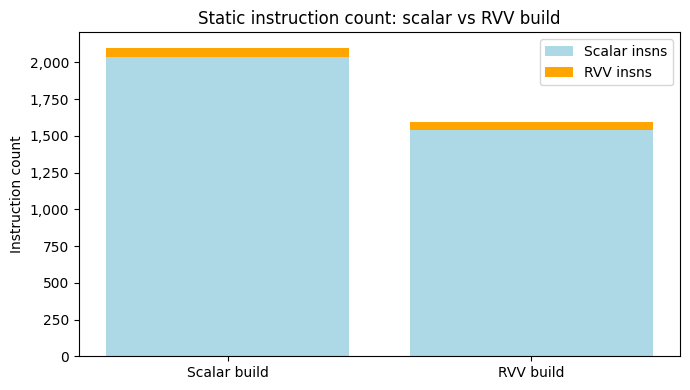

In [54]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

labels  = ["Scalar build", "RVV build"]
s_total = scalar_stats["scalar_total"] + scalar_stats["rvv_total"]
v_total = rvv_stats["scalar_total"]    + rvv_stats["rvv_total"]

scalar_parts = [scalar_stats["scalar_total"], rvv_stats["scalar_total"]]
rvv_parts    = [scalar_stats["rvv_total"],    rvv_stats["rvv_total"]]

x = range(len(labels))
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x, scalar_parts, label="Scalar insns", color="lightblue")
b2 = ax.bar(x, rvv_parts, bottom=scalar_parts, label="RVV insns", color="orange")

ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))
ax.set_ylabel("Instruction count")
ax.set_title("Static instruction count: scalar vs RVV build")
ax.legend()
plt.tight_layout(); plt.show()

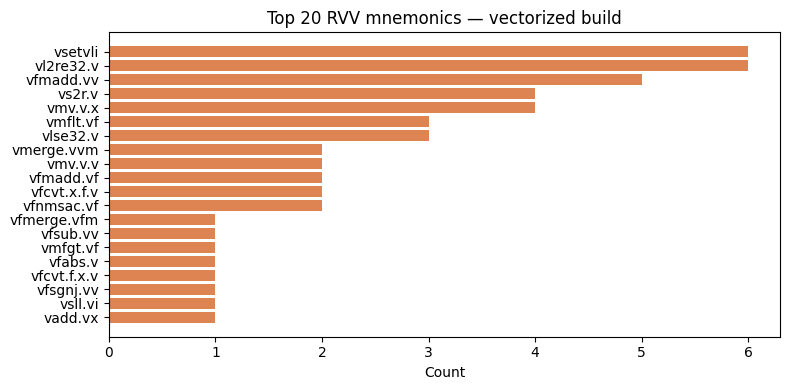

In [36]:
top_n = 20
rvv_items = rvv_stats["rvv"].most_common(top_n)
if rvv_items:
    mnem, cnts = zip(*rvv_items)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(list(reversed(mnem)), list(reversed(cnts)), color="#DD8452")
    ax.set_xlabel("Count")
    ax.set_title(f"Top {top_n} RVV mnemonics — vectorized build")
    plt.tight_layout(); plt.show()
else:
    print("No RVV instructions found — check that vlen=256 target was compiled correctly.")